In [1]:
import numpy as np 
import Physical_Const as phys
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import brenth,brentq

import opacity as op

#----Constants------

hbar     = phys.hbar
c        = phys.c
G        = phys.G
sigma    = phys.sigmaSB
me_mev   = phys.me
e        = phys.e
e_erg    = phys.e_erg
mevtoerg = phys.mevtoerg
mu       = phys.mu
kappaB   = phys.kappa
Msun     = phys.Msun

h     = hbar*(2.0*np.pi)
c2    = c*c
me    = me_mev * mevtoerg / c2
arad  = 4.0*sigma / c
Tr    = me * c2 / kappaB
pi05  = np.sqrt(np.pi)
RBohr = hbar**2 / (me*e_erg)


# ---Dimensions---
MA      = 2.0
Sigma02 = ( mu * MA * np.power(me*c/hbar,3) ) / (3 *np.power(np.pi,2))
Rdim    = c / np.sqrt( Sigma02 * G )
Cgrav   = G * Msun / c2
Mdim    = Rdim / Cgrav
Jdim    = G / c**3

rhobeta=np.log10(3.9e10)

/home/laura/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
# Reproducion Figura 3 y 6 de (Chabrier  & Potekhin, 1998)
Ai = 12
Zi = 6

rhoi = 1e6

f = lambda T: op.Gammanuc(Ai,Zi,rhoi, np.power(10.0,T) ) - 80
Xti =brentq(f, 2, 10)

xT = np.arange(4.5,Xti,0.01)
print(Xti)

Nt = len(xT)
gammas_nm = np.zeros( Nt )
kappaee   = np.zeros(Nt)

for j in range(Nt):
    gammas_nm[j] = op.Gammanuc(Ai,Zi,rhoi, np.power(10.0,xT[j]) )
    kappaee[j]   = op.kcondeeT(Ai,Zi,rhoi, np.power(10.0,xT[j]))

7.3534145063477965


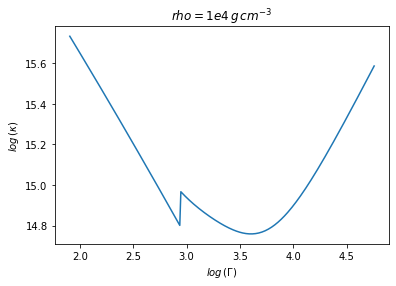

In [5]:
plt.title("$rho=1e4 \, g \, cm^{-3}$")

plt.plot(np.log10(gammas_nm), np.log10(kappaee))


plt.ylabel("$log\, (\kappa)$")
plt.xlabel("$log\, (\Gamma)$")
plt.show()